<h1>Introduction to Adversarial Robustness</h1> 

<h2>Introduction</h2>

This notebook explores the development of an adversarially robust image classifier, a model designed to maintain accuracy even when inputs are subtly modified by a hostile actor.

The project covers the complete workflow:
- data loading and preprocessing
- convolutional neural network design
- standard training
- adversarial attacks
- robust evaluation.
  

<br>Special attention is given to adversarial robustness, including <b>white-box attacks</b> (PGD) and <b>black-box attacks</b> (PSO), highlighting both the challenges and strategies for defending models against malicious perturbations.</br>

<h2>Outline</h2>

- Imports
- Dataset
- Image Classification using a Convolutional Neural Network (CNN)
- Adversarial Robustness
- Resources

<h2>Imports</h2>

In [1]:
# Core PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Computer Vision PyTorch Utilities
import torchvision
import torchvision.transforms as transforms # necessary for DataLoader objects

# Others
import matplotlib.pyplot as plt
import numpy as np

# Seed for Reproducibility
torch.manual_seed(11)
np.random.seed(11)

# Device config - run on GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


<h2>Dataset</h2>

The dataset that is utilized is the CIFAR-10 dataset (<url>https://www.cs.toronto.edu/~kriz/cifar.html</url>)
- Contains 60000 32 $\times$ 32 color images 
- The images belong to 10 different classes: <b>airplanes</b>, <b>automobile</b>, <b>bird</b>, <b>cat</b>, <b>deer</b>, <b>dog</b>, <b>frog</b>, <b>horse</b>, <b>ship</b>, <b>truck</b>
- There are 6000 images of each class 
It is good for quick propotyping before testing on larger datasets (such as the CIFAR-100 or ImageNet) due to reduced complexity requirements and is considered a standard benchmark with non-trivial complexity.

Formally, we assume there exists a formal distribution of data $D$ over the input-label pairs $(x,y)$. However, we do not have access to the true distribution and can only approximate it using a finite dataset $\hat{D}={(x_i,y_i)}$ where $i=1,0,...N$

Samples will be drawn i.i.d from $\hat{D}$ to form the train set $\hat{D}_{train}$ and test set $\hat{D}_{test}$.

<b>Before preprocessing</b>, each image:
- PIL images 
- pixel values $[0,255]$
- shape: $(height, width, channels)$, also noted $H \times W \times C$ 

The <b>PyTorch Neural Network expects</b>:
- PyTorch tensors
- pixel values $[0,1]$
- shape: $(channels, height, width)$, also noted $C \times H \times W$

To bring the images from their original form to the form necessary for utilizing neural network, we can use <b>transforms</b>.\
A transform can be used to convert images to tensors, normalize them and apply data augmentation.

In this scenario, we can also apply some data augmentation transforms such as random crops, flips or rotations, with the purpose of introducing diversity to our data and mitigate overfitting, helping the model generalize better.

<h3>Transformation Pipeline</h3>

First, we define the transformation pipeline. For the train test the following are applied:
- $transforms.RandomCrop(32, padding=4)$: randomly pads an image by 4 pixels on each side and randomply crops a 32 $\times$ 32 region. This introduces translation invariance and prevents overfitting to exact pixel positions
- $transforms.RandomHorizontalFlip()$: randomly flips an image horizontally (with a probability of 0.5). This doubles the effective dataset size. Many objects are symmetric horizontally but vertical flips are avoided to not break semantics. 
- $transforms.ToTensor()$: converts each PIL image to a tensor ($H \times W \times C \rightarrow C \times H \times W$ ), pixel values are scaled from $[0,255]\rightarrow[0,1]$

In [2]:
# Transformations applied to the train set
# Compose creates the piplene
trasform_pipeline_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

<b>Note:</b> For this notebook, only the standard CIFAR-10 training and test splits are used. There is no separate validation set because this notebook is meant for quick experimentation and illustration of adversarial training, not for extensive hyperparameter tuning or model selection.

When it comes to the test transform pipleine, we only transform the images to tensors. The test data must represent the true evaluation distribution and adding randomness would make results noisy and unreliable.

In [3]:
# Transformations applied to the test set
# Compose creates the piplene
trasform_pipeline_test = transforms.Compose([
    transforms.ToTensor(),
])

<h3>Loading the Dataset</h3>

In [4]:
trainset = torchvision.datasets.CIFAR10(
    root="./data",          # data is stored here
    train=True,             # training split = True
    download=True,          # download if dataset is missing (this will take a few minutes)
    transform=trasform_pipeline_train # apply transform pipeline
)


Files already downloaded and verified


C:\Users\Nefeli\anaconda3\envs\pytorch_25\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [5]:
testset = torchvision.datasets.CIFAR10(
    root="./data", # data is stored here
    train=False, # training split = False - this is the test set
    download=True, # download if dataset is missing (this will take a few minutes)
    transform=trasform_pipeline_test # apply transform pipeline
)

Files already downloaded and verified


It is standard practice to use an efficient iterator over the dataset which is implemented via the DataLoader module:
- wraps the Dataset object
- handles: batching, shuffling, collating and parallel loading

Notes:
- a larger batch size will lead to faster training but requires more memory
- a smaller batch can cause noisy gradients

In [6]:
train_loader = torch.utils.data.DataLoader(
    trainset, # dataset to be loaded
    batch_size=128, #each batch contains 128 image tensors, the model processes 128 image tensors at once
    shuffle=True # shuffle data = True - randomize order over each epoch so the model doesn't 'learn' data order accidentally
)

In [7]:
test_loader = torch.utils.data.DataLoader(
    testset,
    batch_size=128, # same batch size as before
    shuffle=False # evaluation is deterministic and order is irrelevant here, the model has not seen this data before
)

To see the contents and shape of a batch:
- apply an iterator
- apply next to yield the batch

The expected shapes are
- image_batch = (128,3,32,32): 128 images in the batch, 3 channels (RGB) and the $32\times 32$ image size
- batch_labels = (128,): a single label for each image in the batch

In [8]:
train_iter = iter(train_loader)
image_batch, batch_labels = next(train_iter)

In [9]:
print(image_batch.shape)
print(batch_labels.shape)

torch.Size([128, 3, 32, 32])
torch.Size([128])


We can also visualize the batch 

The transpose reverts from $ C \times H \times W \rightarrow H \times W \times C $ (with the batch size $B$ in the 0 position)

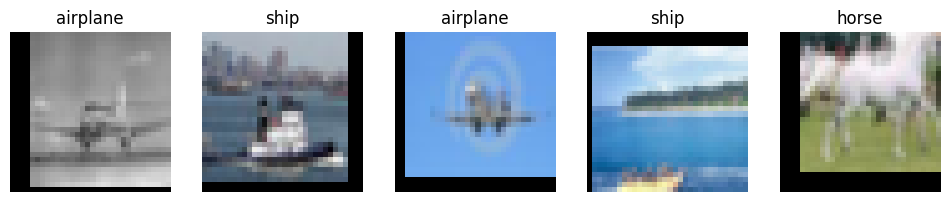

In [10]:
def show_batch_images(image_batch, batch_labels, classes):
    # tensor to numpy array 
    image_nparrays = image_batch.numpy().transpose((0, 2, 3, 1))

    fig, axes = plt.subplots(1, 5, figsize=(12, 3))
    for i in range(5):
        axes[i].imshow(image_nparrays[i])
        axes[i].set_title(classes[batch_labels[i]])
        axes[i].axis("off")


classes = trainset.classes
show_batch_images(image_batch, batch_labels, classes)

We immediatley observe how low the resolution is, but for the purposes of this project it is ok.

<h2>Image Classification with a Convolutional Neural Network (CNN)</h2>

<b>Why use a CNN and not a neural network based on linear layers?</b>
<br></br>
To explain this, it is necessary to remember the differences between convolutional layers and linear layers.

| Feature  | Linear Fully Connected Layer | Convolutional Layer|
| -------- | ------- | ------- |
|Applies| $y=Wx+b$| a convolutional kernel/filter |
| Connectivity | <b>Global</b>, every neuron is connected to every output neuron | <b>Local</b>, each output neuron connects to a small subset of the input neurons |
| Data Structure| Flat vectors | Multi-dimensional tensors |
|Relationships| Ignores spatial or temporal relationships can represent them only if explicitly encoded in the input or architecture) | Preserves spatial or temporal hierarchy|
| Parameter Efficiency | $InputSize\times OutputSize$ weights| Weight sharing, same kernel applied across the entire input|
|Commonly Used For|Tablurar data, final classification layers, Transformer feed forward blocks| Images. video, pattern extraction|



The core idea behind CNN components and their purpose can be summarized as follows:
- The convolutional layers learn what an image is by focusing on spatial relationships. Early layers can detect edges or colors whle deeper layers combine these to detect complex shapes, textures and objects (hierarchical learning). They are efficient because they use the same small filters across the entire image and don't have a unique connection for each pixel.
- Introducing nonlinearity by applying an activation functions such as ReLU to prevent the network from collapsing into linear models.
- Pooling techniques or strided convolutions are employed to shrink the spatial dimensions of the 2D input (dimensionality reduction) while preserving important features.
- The combination of Convolution->ReLU->Pooling detects features, detects features, retains the most important information, and reduces resolution, building an abstract representation of the original data.
- Linear layers are leveraged for classification/decision-making. The linear layer is connected to every extracted feature and can generalise across them. The 2D feature maps are flattened into 1D vectors, and the final computation produces probabilities (via softmax) or direct values for regression tasks.

Given the above, it is clear that <u><b>CNNs are preferred for image classification because they explicitly exploit the spatial structure of image data</b></u>.

<h3>The architecture of the CNN that we will be training </h3>

| Stage | Operation | Comment |
|------|----------|---------|
| Input | 3 × 32 × 32 Image | Raw image data |
| 1 | Convolution | Learn local patterns (edges, textures) |
| 2 | ReLU | Introduce nonlinearity |
| 3 | Max Pool | Reduce spatial resolution |
| 4 | Convolution | Combine lower-level features |
| 5 | ReLU | Nonlinearity |
| 6 | Max Pool | Further downsampling |
| 7 | Flatten | Convert feature maps to vector |
| 8 | Fully Connected | Classification |
| Output | 10 logits | Class scores |


<u>Note:</u>
- <b>Max Pooling</b>: A $2 \times 2$ max pool takes the max value in each $2 \times 2$ region. It halves $W$ and $H$, so $32 \times 32 \rightarrow 16 \times 16$

In [11]:
class CNN(nn.Module):
    """
        A simple CNN to classify images from the CIFAR-10 dataset
        
    """
    
    def __init__(self):
        super().__init__()

        # -------------------------
        # First convolutional layer
        self.conv1 = nn.Conv2d(
            in_channels=3, # Input channels: 3  (RGB)
            out_channels=32, # Output channels: 32 (number of learned filters)
            kernel_size=3, # Kernel size: 3x3 
            padding=1 # Padding: 1 (maintains spatial size)
        )
        # Output shape: (batch_size, 32, 32, 32)
        # -------------------------

        
        # -------------------------
        # Second convolutional layer
        self.conv2 = nn.Conv2d(
            in_channels=32, # Input channels: 32 (from previous layer)
            out_channels=64, # Output channels: 64 (more complex features)
            kernel_size=3, # Kernel size: 3x3 
            padding=1 # Padding: 1 (maintains spatial size)
        )
        # Output shape:(batch_size, 64, 16, 16) after pooling
        # -------------------------

        
        # -------------------------
        # Fully connected layer
        #
        # After two rounds of pooling: 32x32 → 16x16 → 8x8
        #
        # Feature map size: 64 channels × 8 × 8 = 4096 features
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        # -------------------------

        # -------------------------
        # Final classification layer
        # Maps to the 10 CIFAR-10 classes
        self.fc2 = nn.Linear(256, 10)
        # -------------------------

        
    def forward(self, x):
        """
        Defines the forward pass of the network.

        x shape: (batch_size, 3, 32, 32)
        """
        
        # (1) Apply first convolution
        x = self.conv1(x)

        # (2) Apply nonlinearity via ReLU
        x = F.relu(x)

        # (3) Max pooling (2x2): 32x32 -> 16x16
        x = F.max_pool2d(x, kernel_size=2)

        # (4) Apply second convolution
        x = self.conv2(x)
        
        # (5) Apply nonlinearity via ReLU 
        x = F.relu(x)

        # (6) Max pooling (2x2): 16x16 -> 8x8
        x = F.max_pool2d(x, kernel_size=2)

        # (7) Flatten -> Convert from (B, C, H, W) to (B, C*H*W)
        x = x.view(x.size(0), -1) 

        # (8) Fully connected layer 
        x = self.fc1(x)
        x = F.relu(x)

        # Output logits (no softmax here because CrossEntropyLoss applies softmax internally)
        x = self.fc2(x)

        return x


In [12]:
def visualize_feature_maps(model, x):
    """
    Visualize feature maps after the first convolutional layer.
    """
    model.eval()
    with torch.no_grad():
        features = F.relu(model.conv1(x.unsqueeze(0)))

    fig, axes = plt.subplots(4, 8, figsize=(12,6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(features[0, i].cpu(), cmap="gray")
        ax.axis("off")


<h3>Training the CNN and Evaluating its Performance on the Standard Classification Task</h3>

By the "Standard Classification Task" we mean training the model to <b>minimize the emperical risk</b>.
- Learning a model $h_{\theta}: X \rightarrow \mathbb{R}^{10}$ that maps input images $x$to class logits and then pick the class with the highest score
    - $\hat{y}= \arg\max\limits_{c} = h_{\theta}(x)_c$
- Emperical risk is denoted as $\hat{R}(\theta) = \frac{1}{N}\sum_{i=1}^{N}l(h_{\theta}(x_i),y_i)$
    - Where $\theta$ are the learnable parameters and $l(h_{\theta}(x_i),y_i)$ is the <b>cross-entropy loss</b>

The necessary components for training are:
1. The CNN model itself which we built earlier
2. The loss function: the emperical risk
3. The optimizer: usually SGD or Adam 
4. Batching, which is implemented via DataLoader
5. Putting it all together in a training loop with the following main structure:
    - Forward Pass
    - Compute Loss
    - Backward Pass 
    - Update Parameters
<br><b>CAUTION: The gradients must be cleared before the backward pass for PyTorch to not accumulate them and lead to incorrect parameter updates.</b></br> 

In [13]:
### DEFINE MODEL INSTANCE ###
model = CNN().to(device)

In [14]:
### DEFINE OPTIMIZER AND LOSS FUNCTION/CRITERION ###

# Stochastic Gradient Descent
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

# Cross-Entorpy Loss
criterion = nn.CrossEntropyLoss()

In [15]:
### TRAINING ### 

# Number of epochs
num_of_epochs = 50

# Set model to train mode
model.train()

for epoch in range(num_of_epochs):
    running_loss=0
    correct_classifications=0
    total_images = 0

    # iterate over batches
    for batch_i, (inputs, targets) in enumerate(train_loader):
        
        # Move to GPU, if available
        inputs, targets = inputs.to(device), targets.to(device)

        #Clear gradients
        optimizer.zero_grad()

        # Forward pass - compute the predicted outputs 
        pred_outputs = model(inputs)

        #Compute loss
        loss = criterion(pred_outputs, targets)

        #Backpropagate - compute gradient of the loss w.r.t model params
        loss.backward()

        #Update parameters
        optimizer.step()

        #Update runnning statistics
        running_loss += loss.item()*inputs.size(0)
        _,pred_class_idx = pred_outputs.max(1)
        total_images += targets.size(0) # increase by batch size
        correct_classifications+=pred_class_idx.eq(targets).sum().item()

    # Update epoch statistics
    epoch_loss = running_loss/total_images
    epoch_accuracy = correct_classifications/total_images
    
    print(f"Epoch {epoch+1}/{num_of_epochs} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_accuracy:.4f}")

Epoch 1/50 | Loss: 2.0358 | Accuracy: 0.2515
Epoch 2/50 | Loss: 1.6741 | Accuracy: 0.3925
Epoch 3/50 | Loss: 1.4954 | Accuracy: 0.4556
Epoch 4/50 | Loss: 1.4022 | Accuracy: 0.4941
Epoch 5/50 | Loss: 1.3119 | Accuracy: 0.5263
Epoch 6/50 | Loss: 1.2290 | Accuracy: 0.5580
Epoch 7/50 | Loss: 1.1751 | Accuracy: 0.5809
Epoch 8/50 | Loss: 1.1196 | Accuracy: 0.6019
Epoch 9/50 | Loss: 1.0650 | Accuracy: 0.6207
Epoch 10/50 | Loss: 1.0361 | Accuracy: 0.6310
Epoch 11/50 | Loss: 1.0009 | Accuracy: 0.6448
Epoch 12/50 | Loss: 0.9659 | Accuracy: 0.6610
Epoch 13/50 | Loss: 0.9379 | Accuracy: 0.6703
Epoch 14/50 | Loss: 0.9093 | Accuracy: 0.6811
Epoch 15/50 | Loss: 0.8893 | Accuracy: 0.6865
Epoch 16/50 | Loss: 0.8669 | Accuracy: 0.6947
Epoch 17/50 | Loss: 0.8479 | Accuracy: 0.7031
Epoch 18/50 | Loss: 0.8311 | Accuracy: 0.7082
Epoch 19/50 | Loss: 0.8160 | Accuracy: 0.7129
Epoch 20/50 | Loss: 0.7961 | Accuracy: 0.7223
Epoch 21/50 | Loss: 0.7794 | Accuracy: 0.7251
Epoch 22/50 | Loss: 0.7671 | Accuracy: 0.73

<h3>Test Evaluation</h3>

In [16]:
### TEST ###

# Set model to evaluation mode
model.eval()
test_loss = 0
correct_classifications = 0
total_images = 0

#Deactivate gradient computation
with torch.no_grad():
    for inputs, targets in test_loader:
        
        # Move to GPU, if available
        inputs, targets = inputs.to(device), targets.to(device)

        #Make predictions
        pred_outputs = model(inputs)

        #Compute loss
        loss=criterion(pred_outputs,targets)

        test_loss += loss.item()*inputs.size(0)
        _,pred_class_idx = pred_outputs.max(1)
        total_images += targets.size(0) # increase by batch size
        correct_classifications+=pred_class_idx.eq(targets).sum().item()

test_loss = test_loss/total_images
test_accuracy = correct_classifications / total_images
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.6004 | Test Accuracy: 0.7915


Typically, we would fine tune the SGD parameters along with the number of epochs to achieve the best possible for our classifiers, as well as to using other standard metrics such as Precision, Recall, F1-Score to evaluate the model's performance. For now we accept the achieved loss and accuracy as "good enough".

<h2>Adversarial Robustness</h2>

<br>In the standard classification task, the model is trained under the assumption that the test inputs are drawn from the same distribution $(x,y)\sim\hat{D}_{test}$ </br> (i.i.d, emperical sample)

<br> <b>What would happen if a hostile actor slightly modifies the input to make our model malfunction?</b></br>
- For the context of image data, this modification can be invisible to the human eye. A simple addition of inperceptible noise to the image.
- This can result in inconsistent behavior near decision boundaries and misclassification
<br><b>Instead of evaluating the model only at $x$. Would the model be able to make correct predictions for all inputs close to $x$? </b></br>

1. <u>In order to represent the inputs close to $x$, we introduce an <b>adversarial perturbation</b> $\delta$.</u>
- Perturbations are crafted intentionally, small in magnitude and imperceptible to humans
- They are restricted using an $L_p$ norm: $||\delta||_p\leq \epsilon$
- Common norms: $L_{\infty}$ (maximum change of a single pixel),$L_2$ (),$L_1$ (sparse changes)
- For images, a common choice is $L_{\infty}$, so $||\delta||_{\infty}=\max\limits_{i}|\delta_i| $ 
- $\Delta$ is the constraint set bounded by the norm, $\delta$ is bounded in $[-\epsilon,\epsilon]$
- $x+\delta$ is further bounded in $[0,1]$ for the purpose of the image being valid
- Formally: $\Delta(x)={\delta \; | \; ||\delta||_{\infty}\leq\epsilon,\;x+\delta\in[0,1]^{d}}$

2. <u>To form an adversarial example for an <b>untargeted attack</b>:</u>
- An image must be adjusted in a manner that <b><u>maximizes</u></b> the loss: $\max\limits_{\hat{x}}l(h_{\theta}(\hat{x},y)) $
- We actually optimize over a perturbation of x: $\max\limits_{\hat{x}}l(h_{\theta}(x+\delta,y)) $

3. <u>In the scenario of <b>targeted attacks</b>:</u>
- The loss of the correct class is maximized while the loss of the targer class is minimized. The goal is to make the image be classifed as any class we want.
- $\max\limits_{\delta \in \Delta}(l(h_{\theta}(x+\delta,y)) - l(h_{\theta}(x+\delta,y_{target})))=\max\limits_{\delta \in \Delta}(h_{\theta}(x+\delta,y) - h_{\theta}(x+\delta,y_{target}))$

4. Emperical Adversarial Risk: $\hat{R}_{adv}=\frac{1}{|D|}\sum_{(x,y)\in D}\max\limits_{\delta \in \Delta(x)}l(h_{\theta}(x+\delta,y) $
- Worst case scenario of loss in sime region around a single point

5. <u>To train an adversarially robust classifier we have to <b>minimize the emperical adversarial risk</b>:</u>
-  $\min\limits_{\theta}\hat{R}_{adv}(h_{\theta},D_{train}) = \min\limits_{\theta}(\frac{1}{|D_{train}|}\sum_{(x,y)\in D_{train}}\max\limits_{\delta \in \Delta(x)}l(h_{\theta}(x+\delta,y))$
- According to Danskin's Theorem, the gradient of the function involving the max term is guven my the gradient of the function evaluated at this maximum
    - $\delta^{*}=\arg\max\limits_{\delta\in\Delta(x)}l(h_{\theta}(x+\delta,y)$
    - The loss function is differentible w.r.t $\theta$
    - $\nabla_{\theta}(\max\limits_{\delta\in\Delta(x)}l(h_{\theta}(x+\delta,y))=\nabla_{\theta}l(h_{\theta}(x+\delta^{*},y)$
    - $\delta^{*}$ is treated as a constant during differentiation
    - So, the inner problem is solved first before plugging in $\delta=\delta^{*}(x)$ in the outer problem.
    - In real scenarios however, the inner optimization problem is very rarely solved exactly and Danskin's Theorem's conditions are not strictly satisfied. Regardless the same process is followed, relying on acceptable approximations of the internal maximum.

The attacks themselves are focuses on solving the inner maximization problem.

<h3>White-Box Attacks</h3>

In a white-box attack scenario, the adversary has:
- Full access to the model architecture
- Full access to parameters $\theta$
- The ability to compute exact gradients $\nabla_xl$
<br><b>White-box attacks are the strongest attack ("worst case") scenario and define the highest standard for adversarial robustness.</b></br>
<br>Common white-box attacks: </br>
- Fast Gradient Sign Method (FGSM)
- Projected Gradient Descent (PGD)
- Carlini and Wagner attacks(CW attacks)
- Any gradient-based method

We can start with a strong PGD-based hypothetical hostile actor, and train robustness against this attacker.\
<u>Idea:</u> if we train a classifier to be robust against this golden standard, then it will be resistant to equally strong and weaker attacks.

<h4>Adversarial Training</h4>

In the adversarial training case, the model architecture, optimizer, and loss function remain as they are. The only modification is that each training input is replaced by a worst-case adversarial version generated using PGD. The model is then trained to correctly classify these adversarial examples, thereby minimizing empirical adversarial risk.

<br>All we need to do is define a function that generates the worst-case advesarial versions of the input using PGD.</br>

- This function performs a Projected Gradient Descent attack leveraging the $L_{\infty} norm.$
- It knows the model, the inputs, the targets
- It iteratively approximates the solution to the inner maximization problem we defined earlier: $\max\limits_{\delta\in\Delta(x)}l(h_{\theta}(x+\delta,y)) $ 
- The update rule is: $x^{t+1}= \Pi_{x+\Delta}(x^t+\alpha\,sgn(\nabla_{x^{t}}l(h_{\theta}(x^t,y)))$
- $\epsilon$ defines the max perturbation
- $\alpha$ defines the step size
- $steps$ define the number of PGD iterations
- $\nabla_xl$ is the direction of steepest increase in loss w.r.t the input
- $sgn()$ enforces the $L_{\infty}$ constraint  - maximizes the loss while changing each pixel by at most $\alpha$
- $\Pi_{x+\Delta}$ expresses the projection back into the allowed perturbation set 

In [17]:
def pgd_attack_mod(model,inputs,targets,epsilon=8/255,alpha=2/255,steps=10):
    
    # Create independent copy of original data - we don't want to modify the original data
    adv_inputs =  inputs.clone().detach()

    #Rand init within the L-infty norm - "Random Start" - helps avoid bad local maxima 
    adv_inputs+=torch.empty_like(adv_inputs).uniform_(-epsilon,epsilon) # add rand perturbation d in [-e,e]
    adv_inputs = torch.clamp(adv_inputs,0,1) # clamp to [0,1] to ensure image validity

    #PGD iterations
    for s in range(steps):
        # Enable gradient computation w.r.t the input
        adv_inputs.requires_grad = True

        #Forward pass
        pred_outputs = model(adv_inputs)
        
        #Compute loss
        loss = nn.CrossEntropyLoss()(pred_outputs, targets)

        #Compute loss gradients w.r.t. inputs
        gradients = torch.autograd.grad(loss, adv_inputs)[0]

        #Update adv inputs - gradient ascent step
        adv_inputs = adv_inputs.detach() + alpha * gradients.sign() # detach to detach from computationl graph

        #Project the perturbation back into the L-infty ball
        perturbation = torch.clamp(adv_inputs - inputs, -epsilon, epsilon)
        adv_inputs = torch.clamp(inputs + perturbation, 0, 1) # clamp to [0,1] to ensure adv example validity

    return adv_inputs

In [18]:
### DEFINE MODEL INSTANCE ###
model = CNN().to(device)

Important Notes: 
- Training models under adversarial settings is significantly more challenging than standard training
- SGD with momentum is a strong baseline for robust optimization and was a great option for training in the base case.
- Careful hyperparameter tuning is required. However a more practical approach is followed for the purposes of this notebook.
- Something that can help further is utilizing a learning rate scheduler, such as MultiStepLR. This helps stabilize training and improves robust generalization
- Adversarial training typically requires more epochs than natural training
- Running on a GPU is strongly recommended due to the high computational cost of generating adversarial examples

In [19]:
### DEFINE OPTIMIZER AND LOSS FUNCTION/CRITERION ###

#SGD with momentum, as before
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)

#LR scheduler leveraging step decay over epochs
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[50, 75],  # decay LR at 50% and 75% of total epochs
    gamma=0.1
)

# Cross-Entorpy Loss
criterion = nn.CrossEntropyLoss()

In [20]:
### TRAINING ### 

# Number of epochs
num_of_epochs = 65

# Set model to train mode
model.train()

for epoch in range(num_of_epochs):
    running_loss=0
    correct_classifications=0
    total_images = 0

    # iterate over batches
    for batch_i, (inputs, targets) in enumerate(train_loader):
        
        # Move to GPU, if available
        inputs, targets = inputs.to(device), targets.to(device)

        #Clear gradients
        optimizer.zero_grad()

        #Generate adversarial inputs with PGD
        inputs = pgd_attack_mod(model,inputs,targets,epsilon=8/255,alpha=2/255,steps=10)

        # Forward pass - compute the predicted outputs 
        pred_outputs = model(inputs)

        #Compute loss
        loss = criterion(pred_outputs, targets)

        #Backpropagate - compute gradient of the loss w.r.t model params
        loss.backward()

        #Update parameters
        optimizer.step()

        #Update runnning statistics
        running_loss += loss.item()*inputs.size(0)
        _,pred_class_idx = pred_outputs.max(1)
        total_images += targets.size(0) # increase by batch size
        correct_classifications+=pred_class_idx.eq(targets).sum().item()

    # Update epoch statistics
    epoch_loss = running_loss/total_images
    epoch_accuracy = correct_classifications/total_images
    
    print(f"Epoch {epoch+1}/{num_of_epochs} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_accuracy:.4f}")
    scheduler.step()

Epoch 1/65 | Loss: 2.1963 | Accuracy: 0.1807
Epoch 2/65 | Loss: 2.1295 | Accuracy: 0.2123
Epoch 3/65 | Loss: 2.1047 | Accuracy: 0.2201
Epoch 4/65 | Loss: 2.0840 | Accuracy: 0.2238
Epoch 5/65 | Loss: 2.0736 | Accuracy: 0.2291
Epoch 6/65 | Loss: 2.0768 | Accuracy: 0.2266
Epoch 7/65 | Loss: 2.0558 | Accuracy: 0.2345
Epoch 8/65 | Loss: 2.0535 | Accuracy: 0.2341
Epoch 9/65 | Loss: 2.0516 | Accuracy: 0.2362
Epoch 10/65 | Loss: 2.0568 | Accuracy: 0.2352
Epoch 11/65 | Loss: 2.0467 | Accuracy: 0.2378
Epoch 12/65 | Loss: 2.0554 | Accuracy: 0.2351
Epoch 13/65 | Loss: 2.0497 | Accuracy: 0.2357
Epoch 14/65 | Loss: 2.0383 | Accuracy: 0.2410
Epoch 15/65 | Loss: 2.0502 | Accuracy: 0.2354
Epoch 16/65 | Loss: 2.0409 | Accuracy: 0.2388
Epoch 17/65 | Loss: 2.0422 | Accuracy: 0.2407
Epoch 18/65 | Loss: 2.0451 | Accuracy: 0.2335
Epoch 19/65 | Loss: 2.0360 | Accuracy: 0.2396
Epoch 20/65 | Loss: 2.0401 | Accuracy: 0.2394
Epoch 21/65 | Loss: 2.0488 | Accuracy: 0.2373
Epoch 22/65 | Loss: 2.0509 | Accuracy: 0.23

Robust accuracy improves slowly over training and reaches ~0.28 by epoch 60/65. 

During training, the learning rate starts at a relatively high value of 0.1 and remains at this level for the first ~50% of epochs. After the first scheduler milestone, it drops to 0.01 (via the gamma parameter), but we do not observe noticeable improvement until after epoch 50/65, when the learning rate further decreases to 0.001. In the final 15 epochs, robust accuracy gradually increases to ~0.287.

Several factors likely contribute to these dynamics:
- Training setup constraints:
    - Optimizer type and hyperparameters, scheduler type or setup , and number of epochs could be further tuned
- Model capacity:
    - The current small CNN may limit achievable robust accuracy; larger or more complex architectures could improve results
- Adversarial attack strength:
    - PGD-10 with ε=8/255 is a relatively strong perturbation for this model; adjusting ε or step size could facilitate learning
 
At this stage, the results are sufficient to demonstrate adversarial training methodology. 

<b><u>Further experimentation and performance improvements will be explored once GPU resources become available.</u></b>

<h4>Evaluation</h4>

First we run a 'Clean' evaluation loop, with inputs in their original form (no PGD mods). This is the same as the standard classification task.

In [21]:
### CLEAN TEST ###

# Set model to evaluation mode
model.eval()
test_loss = 0
correct_classifications = 0
total_images = 0

#Deactivate gradient computation
with torch.no_grad():
    for inputs, targets in test_loader:
        
        # Move to GPU, if available
        inputs, targets = inputs.to(device), targets.to(device)

        #Make predictions
        pred_outputs = model(inputs)

        #Compute loss
        loss=criterion(pred_outputs,targets)

        test_loss += loss.item()*inputs.size(0)
        _,pred_class_idx = pred_outputs.max(1)
        total_images += targets.size(0) # increase by batch size
        correct_classifications+=pred_class_idx.eq(targets).sum().item()

test_loss = test_loss/total_images
test_accuracy = correct_classifications / total_images
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.4f}")

Test Loss: 1.5144 | Test Accuracy: 0.4794


We can now run a similar evaluation loop, only the inputs are modified using PGD.

In [23]:
### ADVERSARIAL TEST ###


# Set model to eval
model.eval()
test_loss = 0
correct_classifications = 0
total_images = 0

for inputs, targets in test_loader:
    inputs, targets = inputs.to(device), targets.to(device)

    # Generate adversarial inputs (requires grad)
    inputs_adv = pgd_attack_mod(model, inputs, targets, epsilon=8/255, alpha=2/255, steps=10)

    # Now safe to disable gradients for prediction
    with torch.no_grad():
        pred_outputs = model(inputs_adv)
        loss = criterion(pred_outputs, targets)

    test_loss += loss.item() * inputs.size(0)
    _, pred_class_idx = pred_outputs.max(1)
    total_images += targets.size(0)
    correct_classifications += pred_class_idx.eq(targets).sum().item()

test_loss /= total_images
test_accuracy = correct_classifications / total_images
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.4f}")

Test Loss: 1.8524 | Test Accuracy: 0.3027


On the clean test set (without perturbations), the model achieves 0.4794 accuracy, which is expected since it was trained on harder adversarial examples. On the adversarially perturbed test set, accuracy drops to 0.30, consistent with the performance observed during training.

<h3>Black-Box Attacks</h3>

We have thus far trained our model to be adversarially robust to the worst-case scenario. 
Let's investigate the scenario of a <b>black-box attack</b>.

In the black-box scenario:
- the adversary has no access to the internal parameters or gradients of the model
- the advesrary can only query the model with inputs and observe the outputs

<b>So, does adversarial robustness achieved via strong white‑box training translate to robustness against weaker, more realistic attackers?</b>

Some notes about developing a black-box evaluation tool:
- the maximization objective remains the same, it is the available information that differs
- we can use a gradient-free optimization algorithm such as Particle Swarm Optimization (PSO)
- the attacks will be weaker than the PGD-based ones 
- query cost is high - generally computationally expensive
- success is not guaranteed against strongly robust models


PSO in the adversarial setting:
- each particle represents a candidate perturbation $\delta$
- the loss value serves as the <b>fitness function</b>
- particles iteratively move toward perturbations that maximize loss
- all perturbations are constrained to $||\delta||_{\infty}\leq \epsilon$, $x+\delta\in[0,1]^d$
- requires no gradient information
- works directly with model queries
- simple to prototype
- natural fit to black-box threat models

<b>DO NOT RUN THE CELLS BELOW UNLESS GPU IS AVAILABLE - COMPUTATIONALLY EXPENSIVE</b>

In [27]:
import pyswarms as ps

In [43]:
def pso_black_box_attack(model,x,y,epsilon=8/255,num_particles=30,iterations=50,device="cuda"):
    
    #Set model to evaluation mode
    model.eval()

    #Send to GPU
    x=x.to(device)
    y=y.to(device)

    dim = x.numel()  # dimension of the search space

    #Bounds for perturbations - based on L_infty constraint - PSO bounds
    lb = -epsilon * np.ones(dim)
    ub =  epsilon * np.ones(dim)
    bounds = (lb, ub)

    #Define the fitness function
    def fitness_func(deltas):
        losses = []
        for d in deltas:
            # reshape each delta to batch size x channels x H x W
            d_tensor = torch.tensor(d, device=device, dtype=x.dtype).view_as(x)
            adv_x = torch.clamp(x + d_tensor, 0, 1)
            logits = model(adv_x)
            # compute loss per image and sum or mean
            loss = F.cross_entropy(logits, y)  # y already batch_size
            losses.append(-loss.item())
        return np.array(losses)


    #Init PSO - default params for c1,c2 and w
    pso = ps.single.GlobalBestPSO(n_particles=num_particles,dimensions=dim,bounds=bounds, options={"c1": 1.5, "c2": 1.5, "w": 0.7})

    #Optimize the fitness function
    best_cost, best_delta = pso.optimize(fitness_func, iterations)

    #Generate adversarial example and return it
    best_delta = torch.tensor(best_delta, device=device, dtype=x.dtype).view_as(x)
    adv_x = torch.clamp(x + best_delta, 0, 1)

    return adv_x


The pso_black_box function generates an adversarial example using only model queries, by solving a constrained optimization problem with PSO.\
The fitness function assigns a score to each candidate perturbation based on how harmful it is to the model.

In [44]:
### BLACK-BOX PSO TEST ###
correct_classifications = 0
total_images = 0

device = next(model.parameters()).device  # use same device as model

for inputs, targets in test_loader:
    inputs, targets = inputs.to(device), targets.to(device)
    
    
    adv_x = pso_black_box_attack(model,inputs,targets,epsilon=8/255,num_particles=10,iterations=20,device=device)

    with torch.no_grad():
        pred = model(adv_x).argmax(dim=1)

    correct_classifications += (pred == targets[i:i+1]).sum().item()
    total_images += 1

print(f"Black-box PSO accuracy: {correct_classifications / total_images:.4f}")


2026-03-03 22:38:02,529 - pyswarms.single.global_best - INFO - Optimize for 20 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.7}
pyswarms.single.global_best: 100%|██████████████████████████████████████████████████████████████|20/20, best_cost=-1.52
2026-03-03 22:38:33,190 - pyswarms.single.global_best - INFO - Optimization finished | best cost: -1.5177735090255737, best pos: [ 0.02198054 -0.00029532 -0.01124239 ... -0.00257658  0.01929386
 -0.02579628]
2026-03-03 22:38:34,460 - pyswarms.single.global_best - INFO - Optimize for 20 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.7}
pyswarms.single.global_best: 100%|██████████████████████████████████████████████████████████████|20/20, best_cost=-1.58
2026-03-03 22:39:04,523 - pyswarms.single.global_best - INFO - Optimization finished | best cost: -1.5798200368881226, best pos: [-0.02824496  0.01898562  0.00356937 ... -0.02570131 -0.0083028
 -0.00797136]
2026-03-03 22:39:05,334 - pyswarms.single.global_best - INFO - Optimize for 20 iters with {'c1': 1.

Black-box PSO accuracy: 13.1139


The model’s accuracy under the black-box PSO attack is lower than under the white-box attack. This is likely because PSO explores the search space in a population-based, gradient-free manner, meaning it can discover adversarial perturbations that gradient-based attacks didn't reach. This suggests that there may be vulnerable regions in the perturbation space that were not sufficiently explored during the adversarial training of the robust classification model.

<h2>Resources</h2>

Data:
- <url>https://www.cs.toronto.edu/~kriz/cifar.html</url>
- <url>https://docs.pytorch.org/tutorials/beginner/data_loading_tutorial.html</url>


Deep Learning and CNNs:
- <url>https://www.deeplearningbook.org/</url>
- <url>https://cs231n.github.io/neural-networks-2/</url>


Adversarial Robustness:
- <url>https://adversarial-ml-tutorial.org/</url>
- <url>https://arxiv.org/pdf/1706.06083</url>
- <url>https://files.sri.inf.ethz.ch/website/teaching/riai2020/materials/lectures/LECTURE3_ATTACKS.pdf</url>
- <url>https://arxiv.org/pdf/1909.07490</url>